# Hands on lab Day4 Week2


## step 1: Load a provided real dataset and produce a histogram for each numeric variable.

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

df = sns.load_dataset("tips")


total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

In [57]:
df

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


Text(0.5, 1.0, 'total bill histplot')

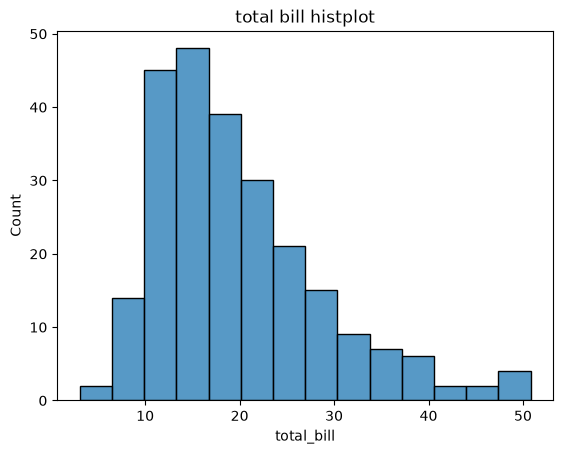

In [43]:
sns.histplot(df,x="total_bill")
plt.title("total bill histplot")

Text(0.5, 1.0, 'tip histplot')

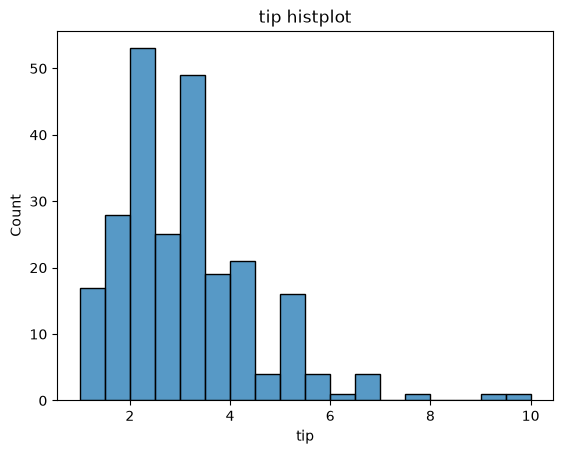

In [44]:
sns.histplot(df,x="tip")
plt.title("tip histplot")

Text(0.5, 1.0, 'size histplot')

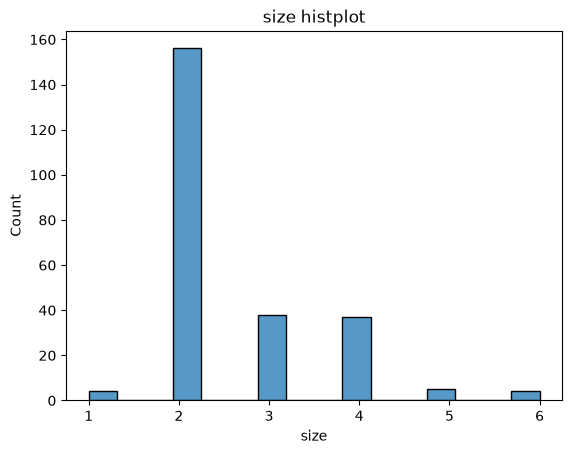

In [45]:
sns.histplot(df,x="size")
plt.title("size histplot")

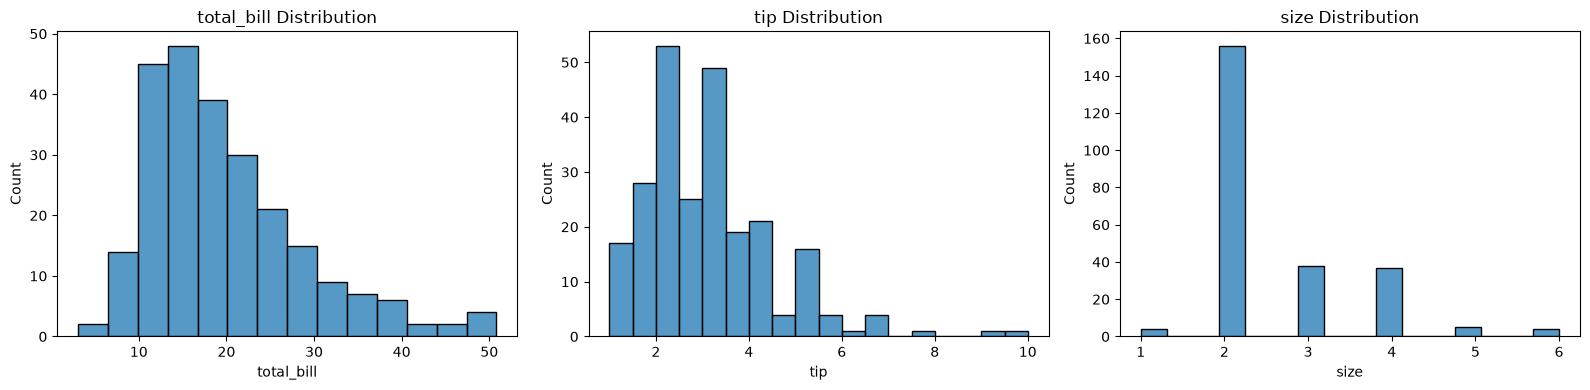

In [46]:
numeric_columns = ["total_bill", "tip", "size"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col in zip(axes, numeric_columns):
    sns.histplot(df, x=col, ax=ax)
    ax.set_title(f"{col} Distribution")

plt.tight_layout()
plt.show()

## Step 2: Produce a box plot for the key numeric variables and identify any outliers visually.

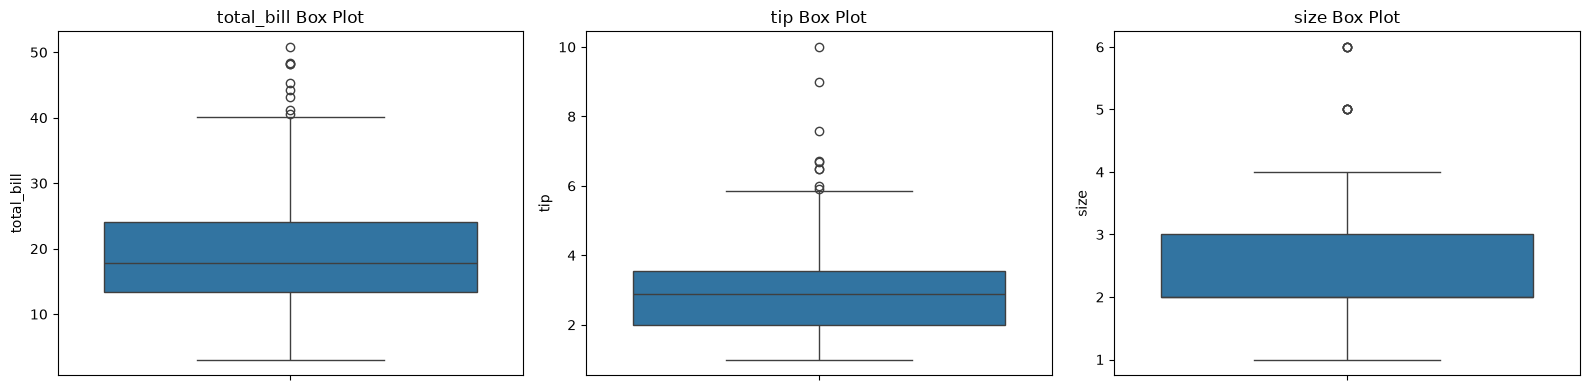

In [47]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col in zip(axes, numeric_columns):
    sns.boxplot(df, y=col, ax=ax)
    ax.set_title(f"{col} Box Plot")

plt.tight_layout()
plt.show()

## Step 3: Apply the IQR method in code to flag outliers in at least one column, and decide (with justification) how to handle them

In [48]:
def find_outliers_iqr(dataframe, column):
    """Return the rows in `column` flagged as outliers by the standard 1.5*IQR rule."""
    Q1 = dataframe[column].quantile(0.25)
    Q3 = dataframe[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return dataframe[(dataframe[column] < lower) | (dataframe[column] > upper)]

for col in numeric_columns:
    found = find_outliers_iqr(df, col)
    print(f"{col}: {len(found)} outlier(s) found")
    if len(found) > 0:
        print(found[[col]].to_string())
    print()

total_bill: 9 outlier(s) found
     total_bill
59        48.27
102       44.30
142       41.19
156       48.17
170       50.81
182       45.35
184       40.55
197       43.11
212       48.33

tip: 9 outlier(s) found
       tip
23    7.58
47    6.00
59    6.73
141   6.70
170  10.00
183   6.50
212   9.00
214   6.50
239   5.92

size: 9 outlier(s) found
     size
125     6
141     6
142     5
143     6
155     5
156     6
185     5
187     5
216     5



IQR flagged 9 outliers in each column (3.69% each) — total_bill, tip, size. Row indices barely overlap, so each is judged separately, not as one cluster.

total_bill: 9 rows, $40–51. Large but plausible bills, not errors. Keep.
tip: 9 rows, $5.92–$10.00. Consistent with high total_bill values (row 170 appears in both). Keep.
size: 9 rows, all parties of 5+. size is a discrete count variable — a group of 5 isn't an anomaly, just a large table. IQR is a weak tool here since it flags anything above the typical 2-4 range regardless of real unusualness. Keep.

Overall: no rows removed — all flagged values are legitimate, not data errors. tips is a small, clean dataset with no real data-quality issues.

## Step 4: Produce a count plot for each categorical variable and note any class imbalance.


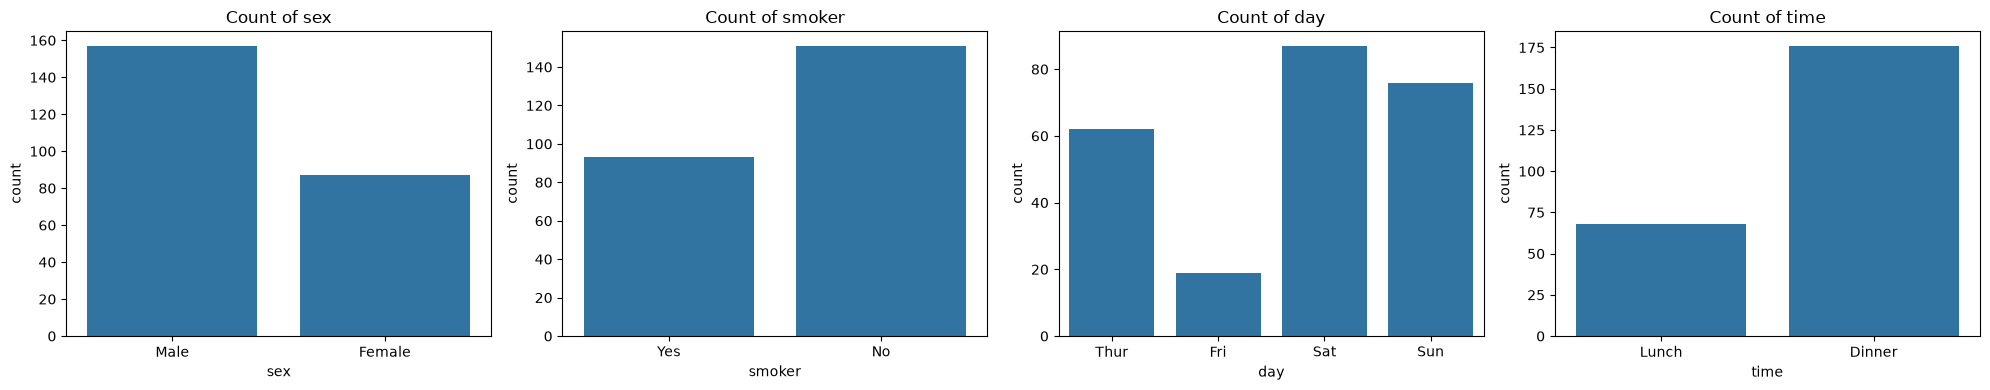

In [49]:
categorical_columns = ["sex", "smoker", "day", "time"]

fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for ax, col in zip(axes, categorical_columns):
    sns.countplot(df, x=col, ax=ax)
    ax.set_title(f"Count of {col}")

plt.tight_layout()
plt.show()

In [50]:
for col in categorical_columns:
    print(df[col].value_counts())
    print()

sex
Male      157
Female     87
Name: count, dtype: int64

smoker
No     151
Yes     93
Name: count, dtype: int64

day
Sat     87
Sun     76
Thur    62
Fri     19
Name: count, dtype: int64

time
Dinner    176
Lunch      68
Name: count, dtype: int64



day shows the sharpest imbalance (Friday is severely underrepresented relative to the other three days), followed by time. sex and smoker are imbalanced but less severely — roughly 2:1 rather than a near-exclusion of one category. If splitting train/test data later, stratify on day at minimum, since a random split risks producing a test set with almost no Friday records.

##  Step 5: Document what each distribution reveals in Markdown cells.


Summary of Distributions

Histograms: total_bill and tip are right-skewed with a long tail of larger values. size clusters around 2-4 people, with a smaller tail of larger parties.

Box plots: All three show points beyond the upper whisker, matching the skew seen above.

IQR: Each column flagged 9 outliers (3.69%). total_bill ($40-51) and tip ($5.92-$10.00) are plausible large transactions — kept. size outliers (parties of 5+) are legitimate group sizes, not errors — kept. IQR is a weaker tool for size since it's a discrete count variable. No rows removed.

Categorical imbalance: day is most imbalanced — Friday (19) vs. Saturday (87). time also imbalanced (Dinner 176 vs. Lunch 68). sex and smoker are imbalanced but milder, roughly 2:1. Stratify on day for any future train/test split.

Overall: clean dataset, no data-quality issues — all outliers are legitimate values. Main concern for modeling is class imbalance, not outliers.